<a href="https://colab.research.google.com/github/osvi-ry/telecom-analysis/blob/main/S7_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
#usd_monthly_pay es un entero (int64)

In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- **Valores faltantes "users":** `city` (11%) y `churn_date` (88%)
- **Valores faltantes "usage":** `date` (1.25%), `duration` (55%) y `length` (~45%)
-
- Indica qué harías: ¿imputar, eliminar, ignorar?
- **En "users":** `city` dejar/mantener como nulos (no son datos numéricos), `churn_date` se elimina porque no figura en el análisis
- **En "usage":** `date`, `duration` y `length` se mantienen como nulos, hasta conocer la influencia en el análisis

# 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# eliminar columna 'churn_date'
users = users.drop(columns='churn_date')

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- **La columna `user_id` sólo tiene registro de 4000 usuarios, pero el promedio y desviación no indican sesgo, ya que no es una variable númerica que repercuta en el análisis.**
- **La columna `age` tiene un valor inválido de -999 (sentinel)**

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- **Las columnas `id` y `user_id` tiene el mismo número de registros (40,000)**
- **Las columnas `duration` y `length` tienen un "count" menor al de 'id' y 'user_id', cuya suma de ambos se obtiene el total de registros (user_id)**

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- **La columna `city` sólo tiene 7 registros, y Bogotá es la que más se repite.**
- **La columna `plan` sólo tiene 2 planes únicos (básico y premium). El plan 'básico' es el más pedido**

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- **La columna `type` tiene sólo 2 tipos de uso (llamada y texto), siendo 'texto' el más utilizado (+22,000 registros)**

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  
 - **En `city` y `date` hay valores inválidos o faltantes**
 - **En `duration` y `length` hay valores faltantes o nulos**
 - **En `age` hay sentinels (-999)**
  
- ¿Qué acción tomarías?
  
 - **En `city` y `date` mantener valores inválidos**
 - **En `duration` y `length` a primera instancia, se podrían imputar valores para capar estadísticas. Sin embargo, requiere de mayor revisión para tomar la decisión**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].max()

Timestamp('2026-05-10 00:00:00')

In [ ]:
users['reg_date'].dt.year

0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
3995    2024
3996    2024
3997    2024
3998    2024
3999    2024
Name: reg_date, Length: 4000, dtype: int64

**En `reg_date`, hay registros del 2022 y 2024**

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].max()

Timestamp('2024-06-30 00:00:00')

In [ ]:
usage['date'].dt.year

0        2024.0
1        2024.0
2        2024.0
3        2024.0
4        2024.0
          ...  
39995    2024.0
39996    2024.0
39997    2024.0
39998    2024.0
39999    2024.0
Name: date, Length: 40000, dtype: float64

**En `date`, sólo hay registros del año 2024**

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- **Hay registros del 2022 en `reg_date`, cuando en "usage" sólo existen registros del 2024.**
- ¿Qué harías con ellas?
- **Podrían ignorarse o  ya que los registros más actuales son del 2024.**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, pd.NA)
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

**Ahora sólo existen 6 de 7 registros originales en `city`, al reemplazar los valores inválidos "?" a NA**

In [ ]:
# Marcar fechas futuras como NA para reg_date
today = pd.Timestamp('today')
users.loc[users['reg_date'] > today, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()


type
call    0.99933
text    0.00000
Name: length, dtype: float64

**En `duration` y `length` están invertidas las cantidades de nulos, ya que 'duration' mide las llamadas, y 'length' mide el tamaño de los mensajes de texto; por tanto, no hay valores mezclados**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(cant_mensajes= ('is_text', 'sum'), cant_llamadas = ('is_call', 'sum'), cant_minutos_llamada = ('duration', 'sum')).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on = 'user_id', how= 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,4.0,3.0,8.01


## 2.2. 4.2 4.2 Resumen estadístico por usuario durante el 2024

### 🎯 **Objetivo**:
Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**
    
- Para las columnas numéricas relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).
- Para la columna categórica plan, revisa la distribución en porcentajes de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_profile = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_profile].describe())

       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

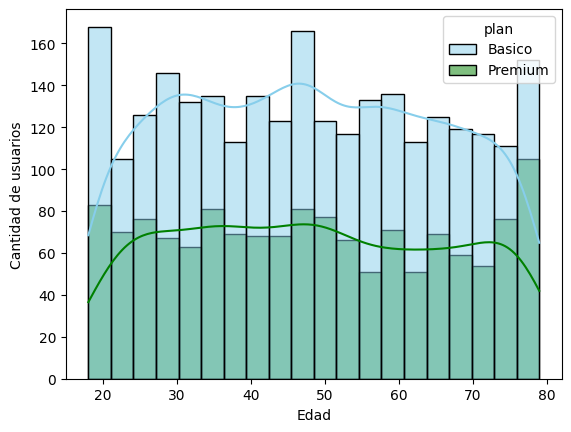

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x='age', hue='plan', bins=20, palette=['skyblue', 'green'], kde=True)

plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- La distribución en el **plan básico** es 'casi' simétrica, sin embargo, existe un **grupo** evidente de usuarios entre **18 y 21 años**, y de **45 a 48 años** que tienen dicho plan.
- La distribución en el **plan premium** es muy estable, con un rango amplio de edades que lo tienen.

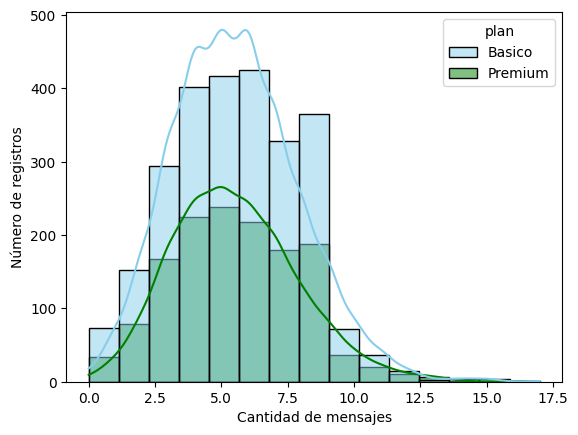

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x='cant_mensajes', hue='plan', bins=15, palette=['skyblue', 'green'], kde=True)

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Número de registros')
plt.show()

💡Insights:
- El comportamiento típico de usuarios con **plan básico** tienden a enviar **más mensajes** que en el plan premium. La media al ser mayor que la mediana, notamos un **sesgo a la derecha**, ya que existen **pocos usuarios** que utilizan **mayor** cantidad de mensajes, especialmente los de **mayor edad.**

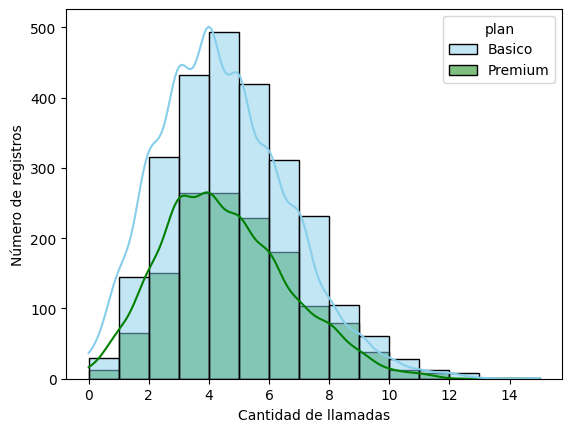

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile, x='cant_llamadas', hue='plan', bins=15, palette=['skyblue', 'green'], kde=True)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de registros')
plt.show()

💡Insights:
- Más de **1200 usuarios** con **plan básico** tienden a hacer entre **4 y 5 llamadas**, comparado a los **500 usuarios** del plan **premium** (3-4 llamadas). La media al ser mayor que la mediana, notamos un sesgo a la derecha, ya que existen **pocos usuarios** que realizan **mayor** cantidad de llamadas, particularmente en usuarios **'adultos'** entre **40 y 50 años.**

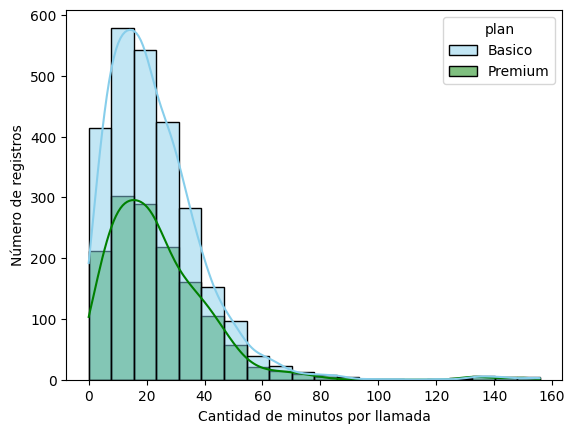

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue', 'green'], kde=True)

plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Número de registros')
plt.show()

💡Insights:
- La distribución tiene un **sesgo a la derecha**, ya que hay muy **pocos usuarios** que **sobrepasan** el promedio de minutos **(~23.3 min)**. Así mismo, el **número de usuarios/registros** en **plan básico** es **congruente** con la cantidad de llamadas realizadas. En cambio, en el **plan 'premium'** el **número de usuarios** que realizan llamadas es cerca de un **40% menor.**

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

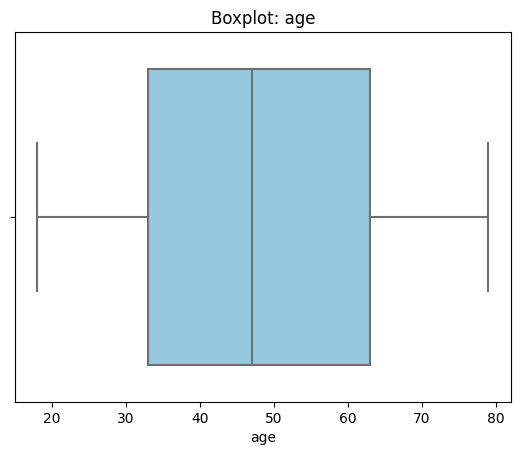

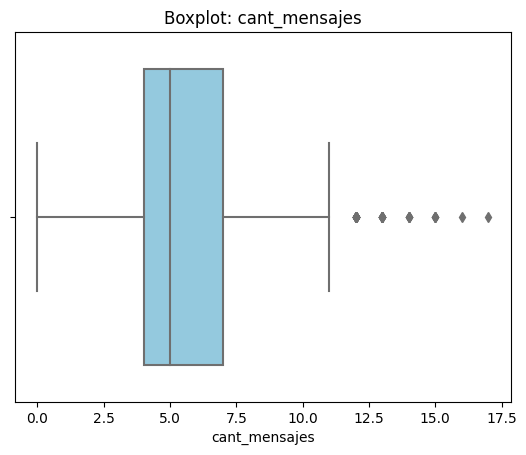

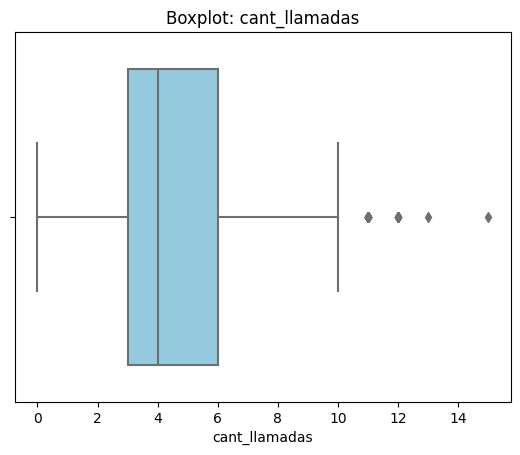

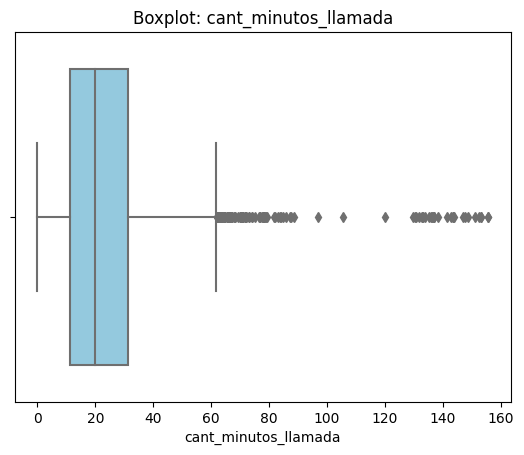

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- **Age**: **no presenta** outliers
- **cant_mensajes**: tiene **pocos outliers**
- **cant_llamadas**: tiene **pocos outliers**
- **cant_minutos_llamada:** hay **muchos outliers** que están **fuera del promedio** de minutos por llamada

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f'Límite inferior {col}:', lower)
    print(f'Límite superior {col}:', upper)
    print(f'Registros fuera límite {col}:', (user_profile[col] > upper).sum())

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

Límite inferior cant_mensajes: -0.5
Límite superior cant_mensajes: 11.5
Registros fuera límite cant_mensajes: 46
Límite inferior cant_llamadas: -1.5
Límite superior cant_llamadas: 10.5
Registros fuera límite cant_llamadas: 30
Límite inferior cant_minutos_llamada: -19.322500000000005
Límite superior cant_minutos_llamada: 61.8575
Registros fuera límite cant_minutos_llamada: 109


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: **se mantienen outliers**, ya que el límite superior no sobrepasa el **máximo real (17.5)**
- cant_llamadas: **se mantienen outliers**, ya que el límite superior no sobrepasa el **máximo real (15)**
- cant_minutos_llamada: **se mantienen outliers**, ya que el número de registros fuera del límite pueden representar un **segmento distinto de clientes** que hacen **mayor uso** de minutos de llamada

---
## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
condiciones_uso = [((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)),
               ((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10))]
opciones_uso = ['Uso bajo', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones_uso, opciones_uso, default= 'Uso alto')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,5.0,10.0,33.18,Uso alto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,11.0,3.0,8.99,Uso alto
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,4.0,3.0,8.01,Uso bajo


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
condiciones_edad = [(user_profile['age'] < 30),
                    (user_profile['age'] > 30) & (user_profile['age'] < 60)]
opciones_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,5.0,10.0,33.18,Uso alto,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,11.0,3.0,8.99,Uso alto,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,4.0,3.0,8.01,Uso bajo,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

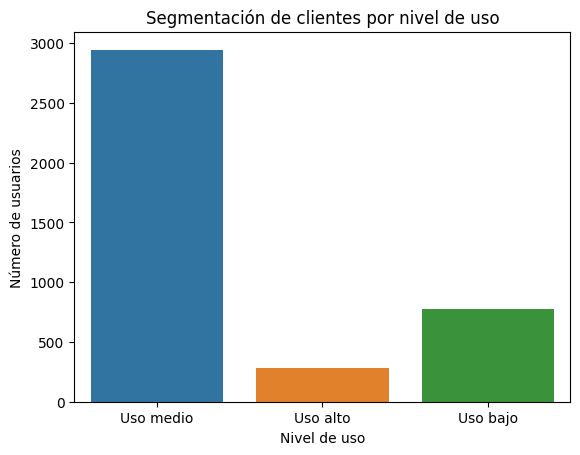

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(user_profile['grupo_uso'])

plt.ylabel('Número de usuarios')
plt.xlabel('Nivel de uso')
plt.title('Segmentación de clientes por nivel de uso')
plt.show()

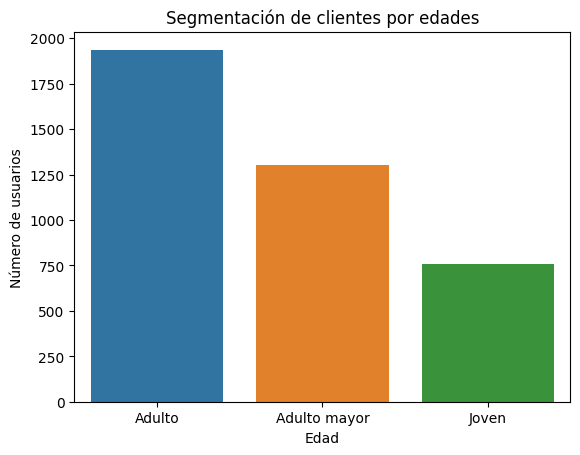

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(user_profile['grupo_edad'])

plt.ylabel('Número de usuarios')
plt.xlabel('Edad')
plt.title('Segmentación de clientes por edades')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna `churn_date` (fecha de cancelación) tenía el **88% de valores inválidos**, por lo que no figuraba en el análisis. Se decidió eliminar del dataframe.
- Existían **valores inválidos** en columna `city`, los cuales se mantuvieron; así como **sentinels** (-999) en la columna `age` el cual se reemplazó por la **mediana**.


🔍 **Segmentos por Edad**
- Existe una mayoría visible de usuarios **'Adultos'** con cerca de **2000 usuarios** de 4000 registros existentes en **2024**.
- El grupo de **'Jóvenes'** es el que **menos usuarios** tiene, en el que puede deducirse que el uso de **'llamadas' y 'texto'** son los **medios menos utilizados** por este grupo


📊 **Segmentos por Nivel de Uso**
- El nivel **'Medio'** presenta la **mayores usuarios**, el cual puede tener relación con la cantidad de usuarios **'Adultos'** que es el **predominante**.
- Aunque el nivel **'Alto'** es el de **menor cantidad** de usuarios, existen clientes que utilizan **mayormente** 'llamadas' **(+60 minutos por mes)**, y 'texto' **(17 mensajes por mes).**


➡️ Esto sugiere que...


💡 **Recomendaciones**
- Implementar **segmento VIP** de 'alto uso' con un plan de **minutos y mensajes 'ilimitados'**, ya que pueden representar **mayores ingresos.**
- Ofrecer un **plan diferenciado** para el grupo de edad **'Joven'** enfocado al uso de **datos móviles**, ya que tienen **menor uso** de 'llamadas' y 'mensajes'.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/osvi-ry/telecom-analysis.git